In [46]:
import os
import re
import gc

import numpy as np
from numpy.random import randint, normal, uniform
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from functools import partial
from joblib import Parallel, delayed

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data, ReducedBispectrum, KSW, Shape
from ksw.radial_functional import radial_func

import h5py
from multiprocessing import cpu_count
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map

from pixell import enmap, reproject, utils, lensing

%matplotlib inline

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, fullsky maps, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}{^{NG}}
$$
and generated the full sky map by passing these $a_{\ell m}$ into healpy.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [47]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000,

    'lmax': 2000,
    'lens_potential_accuracy': 4,


    ## These are forced by ksw
    "DoLateRadTruncation": False,
    "AccuracyBoost":2.,
    # "BessIntBoost": 30.,
    # "KmaxBoost": 3.,
    # "IntTolBoost": 4.,
    # "TimeStepBoost": 4.,
    # "SourcekAccuracyBoost": 5.,
    # "BesselBoost": 5.,
    # "IntkAccuracyBoost": 5.,
    "lSampleBoost": 2.,
    "lAccuracyBoost": 2.,
    # "AccurateBB": True,
}
lmax=cosmo_params['lmax']

camb_params_obj = camb.set_params(**cosmo_params)
print(camb_params_obj)

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_lens
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 3000
 max_l_tensor = 600
 max_eta_k = 72000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02233
 omch2 = 0.1198
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.2458384128277519
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9624
   nr

lmax >= 300 is enforced by the ksw code due to errors with CAMB. 
lmax needs to be somewhat smaller then max_l, if you get errors about c_ell change these.

You will get warning messages if lmax > 4\* nside.  

nside should be of type 2\*\*n

num_patches should be even.

patch_side_deg \* num_patches \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

r_max is given in Mpc, we preform r_res slices over this volume to do the integral. Values have been picked by guestimation, with r_res being set low to help test. Will want to raise this for better calculations.

KSW only supports polarization values of 'T', 'E', ['T', 'E'].

In [48]:
fnl_range=(-1000, 1000)

nsims = 1                   # currently nsims % save_size === 0
npatches = 10                # number of patches to generate per sim

nside=1024

patch_side_deg = 10

r_min = 1                    # Mpc, min radius for the patch     
r_max = 50000                # Mpc, max radius for the patch

# valid values 'T', 'E', ['T', 'E']
polarizations = ['T'] #, 'E']

noise_loc = 0

# Table 1 from smith and zald, planck levels
# nu is 100, 143, 217
# we will used 143 as the base for single value
beam_widths = [9.2, 7.1, 5.0] * u.arcmin*10**-12
noise_scales = [51, 43, 65] * u.arcmin *10**-12# in uK * arcmin

do_lensing = True

save_fullsky = True

force_alm_gen = True 

# For easy switching between notebook and slurm, just disables plots
debug = True

We set the file name best on settings, this will let us load in the data better and ensure we know what settings we are dealing with

In [49]:
if isinstance(polarizations, str):
    chars_of_polarizations = polarizations
elif isinstance(polarizations, list):
    chars_of_polarizations = ''.join(polarizations)
else:
    raise TypeError("polarizations must be either a string or a list of strings")

base_name = f'{nside}_{chars_of_polarizations}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}'
data_dir = f'data/ksw' + ('/lensed' if lensing else '/unlensed')

print(f'running sims for {data_dir}/{base_name}')

running sims for data/ksw/lensed/1024_T_1x10_fnl-1000-1000


In [50]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')
    pattern = re.compile(f"{base_name}\.hdf5(\.nc)?")
    for file in os.listdir(data_dir):
        if pattern.match(file):
            file_path = os.path.join(data_dir, file)
            os.remove(file_path)
            print(f"Deleted existing data file: {file_path}")

def remove_file_if_exists(path):
    if os.path.isfile(path):
        os.remove(path)
        print(f"File {path} has been removed.")

def load_data(data_file, key):
    with h5py.File(data_file, 'r') as hdf:
        return hdf.get(key)[()]

data_filename = f'{base_name}.hdf5.nc'
data_file = os.path.join(data_dir, data_filename)
remove_file_if_exists(data_file)

if save_fullsky:
    fs_filename = f'{base_name}.fullsky.hdf5.nc'
    fs_file = os.path.join(data_dir, fs_filename)
    remove_file_if_exists(fs_file)

alm_filename = f'{base_name}.alms.hdf5.nc'
alm_file = os.path.join(data_dir, alm_filename)

almng_filename = f'{base_name}.alms_ng.hdf5.nc'
almng_file = os.path.join(data_dir, almng_filename)

atest = os.path.join(data_dir, f'{base_name}.alms.hdf5')
btest = os.path.join(data_dir, f'{base_name}.alms_ng.hdf5')          
if not force_alm_gen and os.path.isfile(atest) and os.path.isfile(btest):
    print('Found existing alms, using them')
    alms = load_data(atest, 'alm')
    almngs = load_data(btest, 'almng')
    gen_alms = False
    print('alms loaded', alms.shape)
    print('alm_ng loaded', almngs.shape)
else:
    print('Generating new alms')
    remove_file_if_exists(alm_file)
    remove_file_if_exists(almng_file)

    alms = None
    almngs = None
    gen_alms = True

Reusing directory data/ksw/lensed
Deleted existing data file: data/ksw/lensed/1024_T_1x10_fnl-1000-1000.hdf5
Generating new alms


In [51]:
npol = 1 if isinstance(polarizations, str) else len(polarizations)
pol_b = False #npol > 1 # TODO fix

nell = lmax + 1
nelem = hp.Alm.getsize(lmax)
npix = hp.nside2npix(nside)
ells = np.arange(nell)

pix_size = patch_side_deg*60 / nside #hp.nside2resol(nside, True)          # pixel size in arcmin

alm_ls, alm_ms = hp.Alm.getlm(lmax)

print(npol, pol_b, nell, nelem, npix, pix_size, alm_ls.shape, alm_ms.shape)

1 False 2001 2003001 12582912 0.5859375 (2003001,) (2003001,)


In [52]:
noise_scales_rad = np.array(list(map(lambda x: x.to_value(u.radian), noise_scales)))
beam_widths_rad = np.array(list(map(lambda x: x.to_value(u.radian), beam_widths)))

# Order for pol_b is TT,EE,TE
if pol_b: # TODO
    noise_ell = np.ones((3, nell))*noise_scales_rad[:, np.newaxis]**2

    # I don't think beampol is correct
    beam_ell = hp.gauss_beam(beam_widths_rad[1], lmax, True)
    beam_ell = beam_ell.swapaxes(0,1)[:npol]
else:
    noise_ell = np.ones((nell)) * noise_scales_rad[1]**2
    beam_ell = hp.gauss_beam(beam_widths_rad[1], lmax, False)

print(noise_ell.shape, beam_ell.shape)

(2001,) (2001,)


In [53]:
cosmo = Cosmology(camb_params_obj, verbose=debug)

# Additional settings here, i.e.
# cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

cosmo.compute_transfer(cosmo_params['max_l'])
cosmo.compute_c_ell()

data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo)

Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


For the radii we follow Table 2. of Smith and Zaldarriaga which gives a greater density of points near reionization and recombination. 

Spacing for all ranges but the last row are linear, with the last row having log spacing.

radii are in Mpc

In [54]:
radii = []

#          start,  stop, resolution
ranges = [(    0,  9500, 150), 
          ( 9500, 11000, 300), 
          (11000, 13800, 150), 
          (13800, 14600, 400), 
          (14600, 16000, 100), 
          (16000, 50000, 100)]

for r in ranges:
    if r_max < r[0] or r_min > r[1]:
        continue
    start = max(r_min, r[0])
    end = min(r_max, r[1])
    
    if r == ranges[-1]: # For the last range, use logspace
        temp_radii = np.logspace(np.log10(start), np.log10(end), num=r[2])
    else:
        temp_radii = np.linspace(start, end, num=r[2])
    
    radii.extend(temp_radii[temp_radii <= end])

radii = [r for r in radii if r_min <= r <= r_max]
drs = [j-i for i, j in zip(radii[:-1], radii[1:])]

`radial_func` computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find 
$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$,
and
$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$. 

$\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely (in l) by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations. 

We do this with `CubicSpline`, but this could be changed if needed. 

We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [55]:
c_ells = data.cosmology.c_ell['unlensed_scalar']

tr_ell_k = data.cosmology.transfer['tr_ell_k']
tr_ells = data.cosmology.transfer['ells']
tr_k = data.cosmology.transfer['k']

mask = (tr_ells < lmax)
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

print(c_ells['c_ell'].shape, tr_ell_k.shape, tr_ells.shape, tr_k.shape)

(3001, 4) (126, 32896, 2) (126,) (32896,)


In [56]:
if gen_alms:
    def interpolate_ells(func, ells_sparse, ls, axis=1):
        return CubicSpline(ells_sparse, func, axis)(ls)

    delta_phi = (2 * np.pi) * cosmo_params['As'] * np.sqrt(3 / 5)

    f_k = np.ones((len(tr_k), 2), dtype=float)
    # f_k[:, 0] = 1                           # f_k for alpha
    f_k[:, 1] = tr_k**-3 * delta_phi          # f_k for beta

    rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

    alpha_ell = rad[:,:,:,0]
    alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, ells)]))
    alpha_l = np.ascontiguousarray(alpha_l)

    beta_ell = rad[:,:,:,1]
    c_ells_new = c_ells['c_ell'][tr_ells, :npol]
    div = beta_ell / c_ells_new[np.newaxis, :, :]

    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, ells)]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)

    print(alpha_l.shape, bl_div_cl.shape)

(1200, 2001, 2) (1200, 2001, 2)


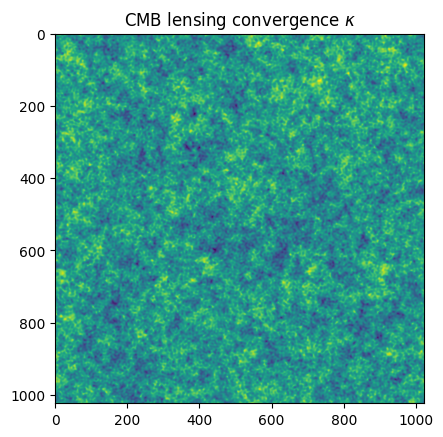

In [57]:
# Lensing code from https://github.com/CMB-S4/CMBAnalysis_SummerSchool/blob/master/CMB_School_Part_10.ipynb

def lens_map(imap,kappa,modlmap,ly,lx,N,pix_size):
    # First we convert lensing convergence to lensing potential
    phi = kappa_to_phi(kappa,modlmap,return_fphi=True)
    # Then we take its gradient to get the deflection field
    grad_phi = gradient(phi,ly,lx)
    # Then we calculate the displaced positions by shifting the physical positions by the deflections
    pos = posmap(N,pix_size) + grad_phi
    # We convert the displaced positions into fractional displaced pixel numbers
    # because scipy doesn't know about physical distances
    pix = sky2pix(pos, N,pix_size)
    # We prepare an empty output lensed map array
    omap = np.empty(imap.shape, dtype= imap.dtype)
    # We then tell scipy to calculate the values of the input lensed map
    # at the displaced fractional positions by interpolation and grid that onto the final lensed map
    from scipy.ndimage import map_coordinates
    map_coordinates(imap, pix, omap, order=5, mode='wrap')
    return omap

# This function needs to know about the Fourier coordinates of the map
def get_ells(N,pix_size):
    # This function returns Fourier wavenumbers for a Cartesian square grid
    N=int(N)
    ones = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.) /(N-1.)
    ell_scale_factor = 2. * np.pi 
    lx = np.outer(ones,inds) / (pix_size/60. * np.pi/180.) * ell_scale_factor
    ly = np.transpose(lx)
    modlmap = np.sqrt(lx**2. + ly**2.)
    return ly,lx,modlmap

# We need to convert kappa to phi
def kappa_to_phi(kappa,modlmap,return_fphi=False):
    return filter_map(kappa,kmask(2./modlmap/(modlmap+1.),modlmap,ellmin=2))

# where we used a Fourier space masking function which will come in handy
def kmask(filter2d,modlmap,ellmin=None,ellmax=None):
    # Apply a minimum and maximum multipole mask to a filter
    if ellmin is not None: filter2d[modlmap<ellmin] = 0
    if ellmax is not None: filter2d[modlmap>ellmax] = 0
    return filter2d

# To do that we also need to know generally how to filter a map
def filter_map(Map,filter2d):
    FMap = np.fft.fftshift(np.fft.fft2(Map))
    FMap_filtered = FMap * filter2d
    Map_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(FMap_filtered)))
    return Map_filtered

# We also need to calculate a gradient
# We do this in Fourier space
def gradient(imap,ly,lx):
    # Filter the map by (i ly, i lx) to get gradient
    return np.stack([filter_map(imap,ly*1j),filter_map(imap,lx*1j)])

# We also needed the map of physical positions
def posmap(N,pix_size):
    pix    = np.mgrid[:N,:N]
    return pix2sky(pix,N,pix_size)

# For that we need to be able to convert pixel indices to sky positions
def pix2sky(pix,N,pix_size):
    py,px = pix
    dec = np.deg2rad((py - N//2 - 0.5)*pix_size/60.)
    ra = np.deg2rad((px - N//2 - 0.5)*pix_size/60.)
    return np.stack([dec,ra])

# Finally, for the lensing operation, we also needed to convert physical sky positions to pixel indices
# which is just the inverse of the above
def sky2pix(pos,N,pix_size):
    dec,ra = np.rad2deg(pos)*60.
    py = dec/pix_size + N//2 + 0.5
    px = ra/pix_size + N//2 + 0.5
    return np.stack([py,px])

def make_CMB_T_map(N,pix_size,ell,ClTT):
    "makes a realization of a simulated CMB sky map given an input DlTT as a function of ell,"
    "the pixel size (pix_size) required and the number N of pixels in the linear dimension."
    #np.random.seed(100)
    # convert Dl to Cl
    # ClTT = DlTT * 2 * np.pi / (ell*(ell+1.))
    ClTT[0] = 0. # set the monopole and the dipole of the Cl spectrum to zero
    ClTT[1] = 0.
    
    # make a 2D real space coordinate system
    onesvec = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.) /(N-1.) # create an array of size N between -0.5 and +0.5
    # compute the outer product matrix: X[i, j] = onesvec[i] * inds[j] for i,j
    # in range(N), which is just N rows copies of inds - for the x dimension
    X = np.outer(onesvec,inds)
    # compute the transpose for the y dimension
    Y = np.transpose(X)
    # radial component R
    R = np.sqrt(X**2. + Y**2.)
    
    # now make a 2D CMB power spectrum
    pix_to_rad = (pix_size/60. * np.pi/180.) # going from pix_size in arcmins to degrees and then degrees to radians
    ell_scale_factor = 2. * np.pi /pix_to_rad  # now relating the angular size in radians to multipoles
    ell2d = R * ell_scale_factor # making a fourier space analogue to the real space R vector
    ClTT_expanded = np.zeros(int(ell2d.max())+1)
    # making an expanded Cl spectrum (of zeros) that goes all the way to the size of the 2D ell vector
    ClTT_expanded[0:(ClTT.size)] = ClTT[:ClTT_expanded.shape[0]] # fill in the Cls until the max of the ClTT vector
    
    # the 2D Cl spectrum is defined on the multiple vector set by the pixel scale
    CLTT2d = ClTT_expanded[ell2d.astype(int)]
    #plt.imshow(np.log(CLTT2d))
    
    
    # now make a realization of the CMB with the given power spectrum in real space
    random_array_for_T = np.random.normal(0,1,(N,N))
    FT_random_array_for_T = np.fft.fft2(random_array_for_T)   # take FFT since we are in Fourier space
    
    FT_2d = np.sqrt(CLTT2d) * FT_random_array_for_T # we take the sqrt since the power spectrum is T^2
    #plt.imshow(np.real(FT_2d))
    
    
    ## make a plot of the 2D cmb simulated map in Fourier space, note the x and y axis labels need to be fixed
    #Plot_CMB_Map(np.real(np.conj(FT_2d)*FT_2d*ell2d * (ell2d+1)/2/np.pi),0,np.max(np.conj(FT_2d)*FT_2d*ell2d * (ell2d+1)/2/np.pi),ell2d.max(),ell2d.max())  ###
    
    # move back from ell space to real space
    CMB_T = np.fft.ifft2(np.fft.fftshift(FT_2d))
    # move back to pixel space for the map
    CMB_T = CMB_T/(pix_size /60.* np.pi/180.)
    # we only want to plot the real component
    CMB_T = np.real(CMB_T)
    
    ## return the map
    return(CMB_T)

# We need to load the theory spectra
def get_theory():
    ells,tt,_,_,pp,_ = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat",unpack=True)
    TCMB2 = 7.4311e12
    ckk = pp/4./TCMB2
    ucltt = tt / ells/(ells+1.)*2.*np.pi
    # ells2,lcltt = np.loadtxt("CMB_fiducial_totalCls.dat",unpack=True,usecols=[0,1])
    # lcltt = lcltt / ells2/(ells2+1.)*2.*np.pi
    # lcltt = lcltt[:len(ells)]
    return ells,ucltt,ckk


lells,lucltt,lclkk = get_theory()

kappa = make_CMB_T_map(nside,pix_size,lells,lclkk)
plt.imshow(kappa)
plt.title('CMB lensing convergence $\kappa$')
plt.show()

In [58]:
def cutSqPatches(fullsky_map, img_size, side_deg, num_patches):
    Tmap_datat = np.zeros((num_patches//2, int(img_size), int(img_size)))
    Tmap_datab = np.zeros((num_patches//2, int(img_size), int(img_size)))

    for counter in range(num_patches//2):
        Tmap_datat[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=0, 
                                                            xsize=img_size, 
                                                            ysize=img_size, 
                                                            rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[0, side_deg],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
        
        Tmap_datab[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=1, 
                                                            xsize=img_size, 
                                                            ysize=img_size, rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[-side_deg, 0],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
    pl.close('all')
    return np.concatenate((Tmap_datat, Tmap_datab))

def cutSqPatches_pixell(do_lensing, shape, wcs, nside, side_deg, num_patches, fullsky_map):
    Tmap_datat = np.zeros((num_patches//2, int(nside), int(nside)))
    Tmap_datab = np.zeros((num_patches//2, int(nside), int(nside)))

    car_map = reproject.healpix2map(fullsky_map, shape, wcs, spin=[0])

    if do_lensing:
        phi_map = enmap.rand_gauss(shape, wcs)
        grad_phi = enmap.grad(phi_map)
        car_map = lensing.lens_map(car_map, grad_phi * 5 * 10**-6)

    for counter in np.arange(num_patches//2):
        box = np.array([[side_deg * counter, 0], [side_deg * (counter + 1), side_deg]]) * utils.degree
        Tmap_datat[counter] = car_map.submap(box)
        
        box = np.array([[side_deg * counter, -side_deg], [side_deg * (counter + 1), 0]]) * utils.degree
        Tmap_datab[counter] = car_map.submap(box)
        
    return np.concatenate((Tmap_datat, Tmap_datab))

res = np.deg2rad(patch_side_deg / nside)
fs_shape, fs_wcs = enmap.fullsky_geometry(res)
cutPatches = partial(cutSqPatches_pixell, do_lensing, fs_shape, fs_wcs, nside, patch_side_deg, npatches)

In [59]:
def _alm_ng(nside, lmax, alm, bl_div_cl, alpha_l, dr, r):
    Balm = hp.almxfl(alm, bl_div_cl)
    B = hp.alm2map(Balm, nside=nside, lmax=lmax, pol=pol_b)
    inner = hp.map2alm(B**2, lmax=lmax, pol=pol_b)
    return dr * r**2 * hp.almxfl(inner, alpha_l)

def get_alm_ng(alm, radii, i, pol):
    funk = partial(_alm_ng, nside, lmax, alm[pol])
    data = Parallel(-1, verbose=0)(delayed(funk)(bl_div_cl[r_idx,:,pol], alpha_l[r_idx,:,pol], dr, r) 
                                   for r_idx, (dr, r) in tqdm(enumerate(zip(drs, radii)), total=len(drs), 
                                                              desc=f'alm[{pol},{i}] progress', disable=not debug))
    return np.sum(data, axis=0)

In [60]:
def save_data(file_path, data_dict):
    compression_opts = dict()  # Compression options
    compression_opts['compression'] = 'gzip'  # Use gzip compression
    compression_opts['compression_opts'] = 9  # Maximum compression level

    with h5py.File(file_path, 'a') as hf:  # Open the file in append mode
        for key, value in data_dict.items():
            if key in hf:
                # Resize the dataset to accommodate the new data
                hf[key].resize((hf[key].shape[0] + value.shape[0],) + value.shape[1:])
                # Append the new data
                hf[key][-value.shape[0]:] = value
            else:
                # Create a new dataset for this key with compression options
                hf.create_dataset(key, data=value, maxshape=(None,) + value.shape[1:], **compression_opts)

In [61]:
def run_sim(alm, alm_ng):    
    fnl = uniform(fnl_range[0], fnl_range[1])
    alm_prime = alm + fnl * alm_ng
    
    map = np.array([hp.alm2map(alm_prime[pol], nside, lmax=lmax, pol=pol_b) for pol in range(npol)])
    patches = np.array([cutPatches(map[pol]) for pol in range(npol)])
    return alm, alm_ng, fnl, map, patches


In [62]:
for i in tqdm(range(nsims), desc='Simulation progress'):
    if gen_alms:
        alm = data.compute_alm_sim(False)
        
        radii = radii[:100]
        alm_ng = np.array([get_alm_ng(alm, radii, i, pol) for pol in range(npol)])
    else:
        alm = alms[i]
        alm_ng = almngs[i] 

    alm, almng, fnl, fsmap, patches = run_sim(alm, alm_ng)

    if gen_alms:
        save_data(alm_file, {'alm': alm[np.newaxis]})
        save_data(almng_file, {'almng': almng[np.newaxis]})
        
    if save_fullsky:
        save_data(fs_file, {'map': fsmap[np.newaxis]})

    sdata = {}
    sdata['fnls'] = np.array([fnl])
    sdata['patches'] = patches[np.newaxis]
    save_data(data_file, sdata)

Simulation progress:   0%|          | 0/1 [00:00<?, ?it/s]

alm[0,0] progress:   0%|          | 0/1199 [00:00<?, ?it/s]

In [63]:
def rename_save(file_name):
    new_file = file_name.replace('.hdf5.nc', '.hdf5')
    remove_file_if_exists(new_file)
    os.rename(file_name, new_file)
    print('Data saved to', new_file)

rename_save(data_file)

if gen_alms:
    rename_save(alm_file)
    rename_save(almng_file)

if save_fullsky:
    rename_save(fs_file)

Data saved to data/ksw/lensed/1024_T_1x10_fnl-1000-1000.hdf5
File data/ksw/lensed/1024_T_1x10_fnl-1000-1000.alms.hdf5 has been removed.
Data saved to data/ksw/lensed/1024_T_1x10_fnl-1000-1000.alms.hdf5
File data/ksw/lensed/1024_T_1x10_fnl-1000-1000.alms_ng.hdf5 has been removed.
Data saved to data/ksw/lensed/1024_T_1x10_fnl-1000-1000.alms_ng.hdf5
File data/ksw/lensed/1024_T_1x10_fnl-1000-1000.fullsky.hdf5 has been removed.
Data saved to data/ksw/lensed/1024_T_1x10_fnl-1000-1000.fullsky.hdf5


In [64]:
print('Done with Generation!') 
if not debug:
    exit(0)        

Done with Generation!


---

# Plots

In [65]:
random_indices = [(0,0)] #(randint(npol), randint(npatches)) for _ in range(1)]

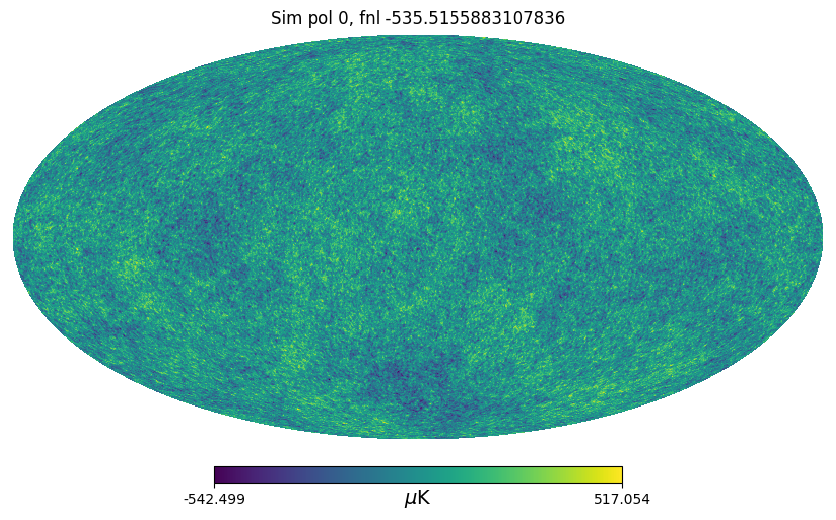

In [66]:
for p, _ in random_indices:
    hp.mollview(fsmap[p], title=f'Sim pol {p}, fnl {fnl}', unit='$\mu$K')

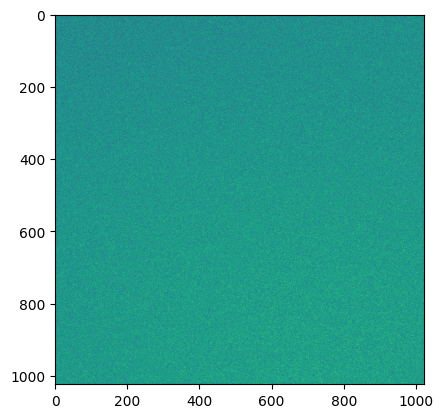

In [67]:
for p, n in random_indices:
    plt.imshow(patches[p, n])

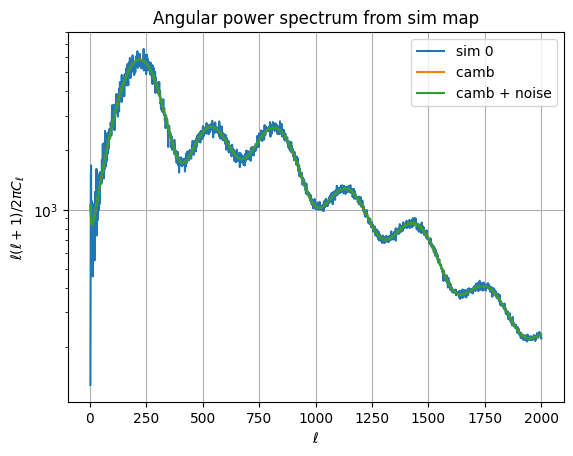

In [68]:
cl = hp.anafast(fsmap[0], lmax=lmax, pol=pol_b, use_pixel_weights=True)
ell = np.arange(len(cl))

plt.semilogy(ell[2:], (ell * (ell + 1) / 2 / np.pi)[2:] * cl[2:], label=f'sim {0}')

noise_ell_b = np.array([noise_scales_rad[1]**2 * np.exp( (l*(l+1) * beam_widths_rad[1]**2) / (8*np.log(2)) ) for l in range(nell)])
camb_cls_n = c_ells['c_ell'][2:lmax] + noise_ell_b[2:lmax, np.newaxis]
camb_ls = np.arange(2, lmax)

plt.semilogy(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * c_ells['c_ell'][2:lmax][:, 0], label='camb ')
plt.semilogy(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls_n[:, 0], label='camb + noise')

plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)/2\pi C_{\ell}$")
plt.title(f'Angular power spectrum from sim map')
plt.legend()
plt.grid()

# Goodbye